In [ ]:
# Import necessary libraries
# BY SHLOK VIJ 23070521143
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
print("Train and Test datasets loaded successfully.")
print("Train data head:")
display(train.head())
print("\nTest data head:")
display(test.head())

Train and Test datasets loaded successfully.
Train data head:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Test data head:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

train.info()
train.describe()
train.isnull().sum()
train.dtypes
X = train.drop("SalePrice", axis=1)
y = train["SalePrice"]
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

num_imputer = SimpleImputer(strategy="median")
X[num_cols] = num_imputer.fit_transform(X[num_cols])

cat_imputer = SimpleImputer(strategy="most_frequent")
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])
X = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()

X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))

model.add(Dense(64, activation='relu'))

model.add(Dense(32, activation='relu'))

model.add(Dense(1))
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        31,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,857 (163.50 KB)

 Trainable params: 41,857 (163.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 39145172992.0000 - mae: 181522.0625 - val_loss: 37836824576.0000 - val_mae: 181089.0938
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39126249472.0000 - mae: 181480.3438 - val_loss: 37793116160.0000 - val_mae: 180993.5000
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39000756224.0000 - mae: 181222.7188 - val_loss: 37549215744.0000 - val_mae: 180480.1719
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 38486974464.0000 - mae: 180166.9219 - val_loss: 36716097536.0000 - val_mae: 178713.8125
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36963323904.0000 - mae: 177016.2812 - val_loss: 34595856384.0000 - val_mae: 174075.2969
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 33621860352.0000 - mae: 169696.7344 - val_loss: 30367961088.0000 - val_mae: 164130.5469
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 27770720256.0000 - mae: 155248.5312 - val_loss: 23983271936

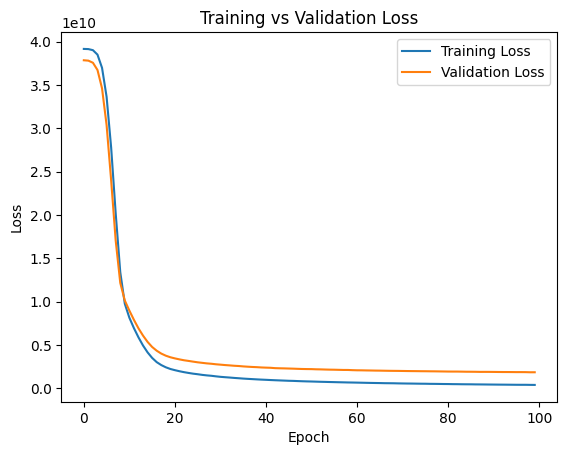

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [ ]:
y_pred = model.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
MAE : 26203.251953125
MSE : 1786924288.0
RMSE: 42272.02725207297


In [ ]:
# Import necessary Keras components
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the Feedforward Neural Network model
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(1)) # Output layer for regression (single continuous value)

# Compile the model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print("Model defined and compiled successfully.")
model.summary()

Model defined and compiled successfully.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │        31,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,857 (163.50 KB)

 Trainable params: 41,857 (163.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Install pydot and graphviz for model visualization
!pip install pydot
!pip install graphviz

import pydot
import graphviz
from tensorflow.keras.utils import plot_model

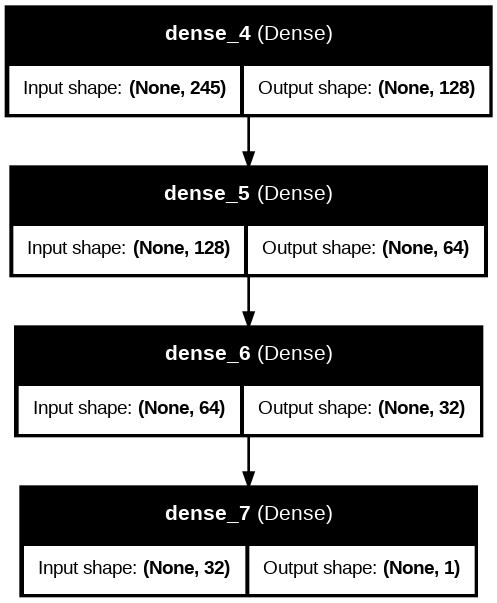

In [ ]:
# Visualize the current model architecture
plot_model(
    model,
    to_file='current_model_architecture.png',
    show_shapes=True,
    show_layer_names=True,
    rankdir='TB', # 'TB' for top-to-bottom, 'LR' for left-to-right
    expand_nested=False,
    dpi=96
)

from IPython.display import Image
Image(filename='current_model_architecture.png')


In [ ]:
# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=100, # Number of epochs can be adjusted
    batch_size=32, # Batch size can be adjusted
    validation_split=0.2, # 20% of training data used for validation
    verbose=1 # Show progress bar during training
)

print("Model training complete.")

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 39143370752.0000 - mae: 181517.4062 - val_loss: 37832269824.0000 - val_mae: 181077.2344
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39112007680.0000 - mae: 181446.3281 - val_loss: 37764214784.0000 - val_mae: 180923.7188
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 38934183936.0000 - mae: 181061.8750 - val_loss: 37423493120.0000 - val_mae: 180184.3438
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 38197043200.0000 - mae: 179530.5000 - val_loss: 36275310592.0000 - val_mae: 177679.2344
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 36204789760.0000 - mae: 175210.1094 - val_loss: 33525563392.0000 - val_mae: 171463.1562
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 32005646336.0000 - mae: 165726.9219 - val_loss: 28586745856.0000 - val_mae: 159231.7031
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 25451089920.0000 - mae: 148399.7031 - val_loss: 2141590937

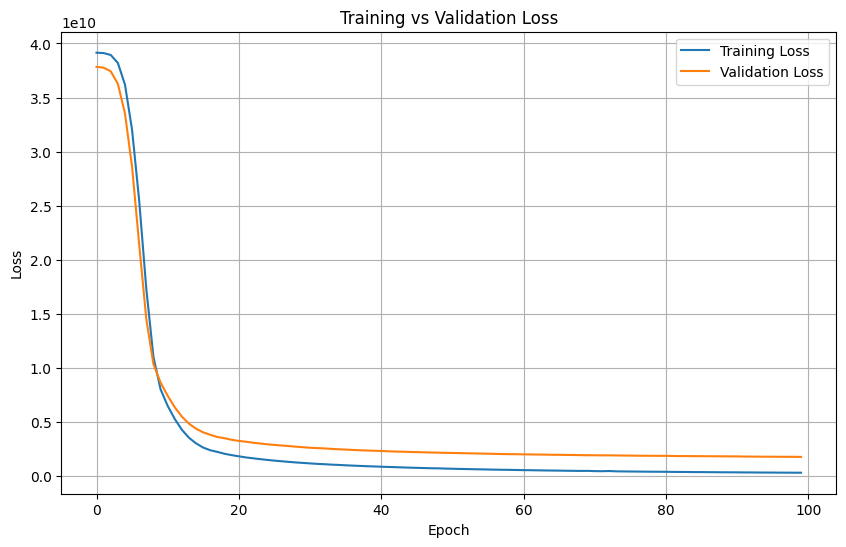

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

print("\nModel evaluation complete. You can now analyze these metrics to understand the model's performance.")

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Mean Absolute Error (MAE): 26097.0117
Mean Squared Error (MSE): 1802902400.0000
Root Mean Squared Error (RMSE): 42460.5982

Model evaluation complete. You can now analyze these metrics to understand the model's performance.


In [ ]:
def build_model(num_hidden_layers, neurons_per_layer_list, input_shape, activation='relu'):
    """
    Creates a Keras Sequential model with a specified number of hidden layers,
    neuron counts, input shape, and activation function.

    Args:
        num_hidden_layers (int): The number of hidden layers.
        neurons_per_layer_list (list): A list of integers, where each element
                                     represents the number of neurons in a
                                     corresponding hidden layer.
        input_shape (tuple): The input shape of the model.
        activation (str): The activation function for the hidden layers (default is 'relu').

    Returns:
        tf.keras.Model: The compiled Keras Sequential model.
    """
    model = keras.Sequential()

    # Add the input layer (which is technically the first hidden layer in Keras Sequential)
    # with input_shape. The number of neurons for this layer is the first in the list.
    if num_hidden_layers > 0:
        model.add(layers.Dense(neurons_per_layer_list[0], activation=activation, input_shape=input_shape))

        # Add subsequent hidden layers if any
        for i in range(1, num_hidden_layers):
            model.add(layers.Dense(neurons_per_layer_list[i], activation=activation))

    # Output layer for regression (single neuron, no activation)
    model.add(layers.Dense(1))

    # Compile the model
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    return model

# Test the function: Create a model with 1 hidden layer (e.g., 64 neurons)
# using the input shape from our preprocessed data (X_train.shape[1])
input_dim = X_train.shape[1]
sample_model_1_layer = build_model(
    num_hidden_layers=1,
    neurons_per_layer_list=[64],
    input_shape=(input_dim,)
)

print("1-Hidden-Layer Model Summary:")
sample_model_1_layer.summary()

1-Hidden-Layer Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 64)             │        15,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,809 (61.75 KB)

 Trainable params: 15,809 (61.75 KB)

 Non-trainable params: 0 (0.00 B)